# 🏀 NBA Player Performance Analysis
## Evolution of 3-Point Shooting & Scoring Efficiency (2010–2025)

---

**Domain:** Sports Analytics — NBA  
**Dataset:** NBA Player Stats and Salaries 2010–2025 (Kaggle)  
**Tools:** Python, Pandas, Matplotlib, Seaborn  

---

### Problem Statement
The NBA has undergone a significant transformation over the past 15 years. Teams and players have increasingly shifted from traditional 2-point scoring to 3-point shooting. This project analyzes **how 3-point shooting and scoring efficiency has evolved from 2010 to 2025**, and identifies which players, positions, and seasons drove that change.

### Research Questions
1. How much have 3-point attempts increased over the years?
2. Which positions adopted 3-point shooting the most?
3. Who are the most efficient and prolific 3-point shooters?
4. Does shooting efficiency correlate with higher salary?
5. How has overall scoring efficiency (eFG%) changed across eras?

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global style settings
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({
    "figure.facecolor": "#f9f9f9",
    "axes.facecolor":   "#f9f9f9",
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   14,
    "axes.labelsize":   12,
})

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## Step 2 — Load Dataset

### Dataset Description
| Column | Description |
|--------|-------------|
| Player | Player name |
| Salary | Annual salary (USD) |
| Year | Season year |
| Pos | Position (PG, SG, SF, PF, C) |
| Age | Player age |
| Team | Team abbreviation |
| G | Games played |
| MP | Minutes per game |
| FG, FGA, FG% | Field goals made, attempted, % |
| 3P, 3PA, 3P% | 3-pointers made, attempted, % |
| 2P, 2PA, 2P% | 2-pointers made, attempted, % |
| eFG% | Effective field goal % |
| FT, FTA, FT% | Free throws made, attempted, % |
| ORB, DRB, TRB | Offensive, defensive, total rebounds |
| AST, STL, BLK | Assists, steals, blocks |
| TOV, PF, PTS | Turnovers, fouls, points per game |

In [2]:
# Load the dataset
df = pd.read_csv('NBA Player Stats and Salaries_2010-2025.csv')

print(f"Shape           : {df.shape}")
print(f"Seasons covered : {sorted(df['Year'].unique())}")
print(f"Total players   : {df['Player'].nunique()}")
print()
df.head()

Shape           : (7298, 31)
Seasons covered : [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Total players   : 1658



,Player,Salary,Year,Pos,Age,Team,G,GS,MP,FG,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,Kobe Bryant,23034375,2010,SG,31,LAL,73,73,38.8,9.8,...,0.811,1.1,4.3,5.4,5.0,1.5,0.3,3.2,2.6,27.0
1,Jermaine O'Neal,23016000,2010,C,31,MIA,70,70,28.4,5.6,...,0.720,1.8,5.2,6.9,1.3,0.4,1.4,1.8,3.0,13.6
2,Tracy McGrady,22843124,2010,SG,30,NYK,30,24,22.4,3.0,...,0.746,0.7,2.4,3.1,3.3,0.5,0.5,1.5,1.3,8.2
3,Tim Duncan,22183220,2010,C,33,SAS,78,77,31.3,7.2,...,0.725,2.8,7.3,10.1,3.2,0.6,1.5,1.8,1.9,17.9
4,Shaquille O'Neal,21000000,2010,C,37,CLE,53,53,23.4,4.9,...,0.496,1.8,4.9,6.7,1.5,0.3,1.2,2.0,3.2,12.0


## Step 3 — Data Cleaning

**Issues to handle:**
- NaN values in percentage columns (players who never attempted that shot type)
- Multi-position labels (e.g. `PG-SG`) — standardize to primary position
- Low-minute players (G < 10) who skew percentage stats
- Separate 2025 (incomplete season) from trend analysis
- Add Era labels for era-based comparisons

In [3]:
# Check missing values before cleaning
print("Missing values before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values before cleaning:
FG%      20
3P%     585
2P%      45
eFG%     20
FT%     202
dtype: int64


In [4]:
# 1. Fill NaN % columns with 0 (player never attempted that shot type)
pct_cols = ['FG%', '3P%', '2P%', 'eFG%', 'FT%']
df[pct_cols] = df[pct_cols].fillna(0)

# 2. Standardize multi-position labels to primary position only
df['Pos'] = df['Pos'].str.split('-').str[0]

# 3. Filter out players with fewer than 10 games
before = len(df)
df = df[df['G'] >= 10].reset_index(drop=True)
print(f"Rows removed (G < 10) : {before - len(df)}")
print(f"Rows remaining        : {len(df)}")

# 4. Add Era column
def assign_era(year):
    if year <= 2014:
        return "Pre-Revolution (2010-2014)"
    elif year <= 2019:
        return "Transition (2015-2019)"
    else:
        return "3PT Dominant (2020-2025)"

df['Era'] = df['Year'].apply(assign_era)

# 5. Separate trend dataset (exclude 2025 incomplete season)
df_trend = df[df['Year'] <= 2024].copy()

print()
print("Missing values after cleaning:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing[missing > 0].any() else "None ✅")
print()
print("Positions after standardization:", df['Pos'].unique())
print()
print("✅ Data Cleaning Complete!")

Rows removed (G < 10) : 591
Rows remaining        : 6707

Missing values after cleaning:
None ✅

Positions after standardization: ['SG' 'C' 'PF' 'SF' 'PG']

✅ Data Cleaning Complete!


## Step 4 — Exploratory Data Analysis (EDA)

In [5]:
# Basic statistics of key columns
df[['PTS','3P','3PA','3P%','eFG%','Salary']].describe().round(2)

,PTS,3P,3PA,3P%,eFG%,Salary
count,6707.00,6707.00,6707.00,6707.00,6707.00,6707.00
mean,9.22,0.86,2.41,0.29,0.51,6905060.83
std,6.10,0.81,2.12,0.15,0.07,8708127.49
min,0.00,0.00,0.00,0.00,0.00,4737.00
25%,4.60,0.10,0.50,0.25,0.47,1473420.00
50%,7.80,0.70,2.10,0.33,0.51,3333333.00
75%,12.45,1.30,3.70,0.38,0.55,8984882.50
max,36.10,5.30,13.20,1.00,0.85,55761216.00


In [6]:
# Players per season
print("Players per Season:")
print(df_trend.groupby('Year')['Player'].count().to_string())

Players per Season:
Year
2010    404
2011    411
2012    421
2013    408
2014    394
2015    435
2016    417
2017    426
2018    368
2019    425
2020    411
2021    443
2022    448
2023    405
2024    431


In [7]:
# Average age per season
print("Average Age per Season:")
print(df_trend.groupby('Year')['Age'].mean().round(1).to_string())

Average Age per Season:
Year
2010    26.6
2011    26.6
2012    26.7
2013    26.6
2014    26.4
2015    26.7
2016    26.7
2017    26.4
2018    26.1
2019    26.2
2020    25.9
2021    25.6
2022    26.0
2023    25.9
2024    25.9


## Step 5 — Visualizations

### Chart 1 — League-Wide 3-Point Revolution Trends (2010–2024)

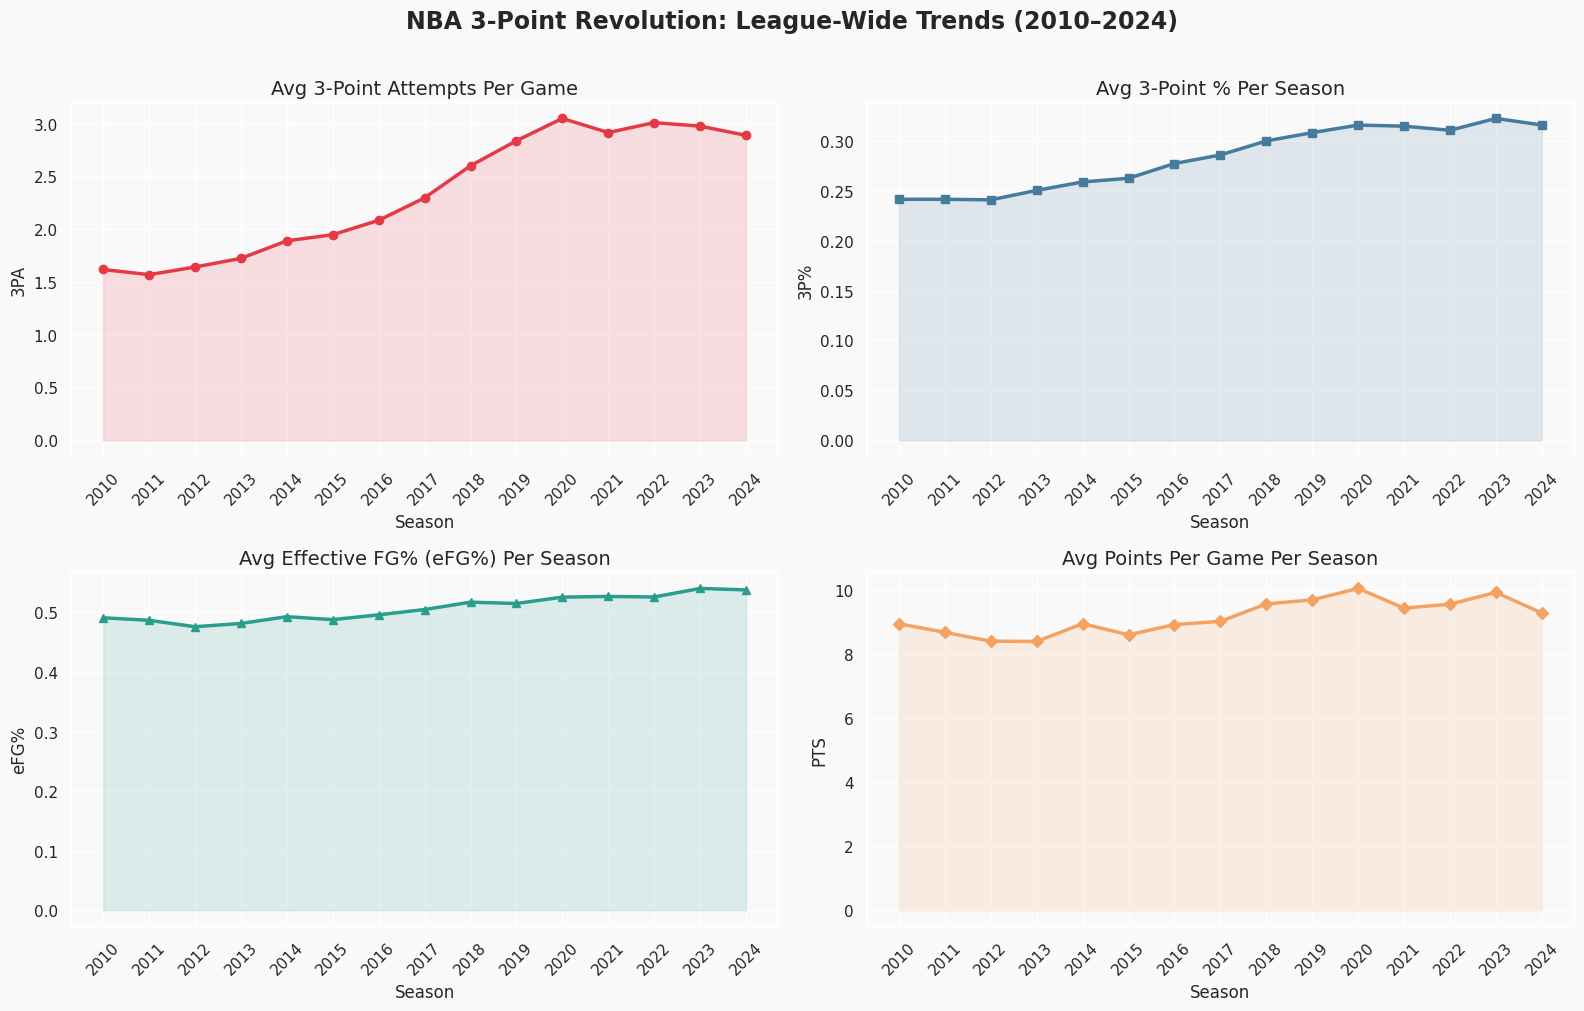

In [8]:
season_avg = df_trend.groupby('Year')[['3PA','3P','3P%','2PA','2P','eFG%','PTS','FG%']].mean().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("NBA 3-Point Revolution: League-Wide Trends (2010–2024)",
             fontsize=17, fontweight='bold', y=1.01)

# 3PA
ax1 = axes[0][0]
ax1.plot(season_avg['Year'], season_avg['3PA'], marker='o', color='#e63946', linewidth=2.5)
ax1.fill_between(season_avg['Year'], season_avg['3PA'], alpha=0.15, color='#e63946')
ax1.set_title("Avg 3-Point Attempts Per Game")
ax1.set_xlabel("Season"); ax1.set_ylabel("3PA")
ax1.set_xticks(season_avg['Year']); ax1.tick_params(axis='x', rotation=45)

# 3P%
ax2 = axes[0][1]
ax2.plot(season_avg['Year'], season_avg['3P%'], marker='s', color='#457b9d', linewidth=2.5)
ax2.fill_between(season_avg['Year'], season_avg['3P%'], alpha=0.15, color='#457b9d')
ax2.set_title("Avg 3-Point % Per Season")
ax2.set_xlabel("Season"); ax2.set_ylabel("3P%")
ax2.set_xticks(season_avg['Year']); ax2.tick_params(axis='x', rotation=45)

# eFG%
ax3 = axes[1][0]
ax3.plot(season_avg['Year'], season_avg['eFG%'], marker='^', color='#2a9d8f', linewidth=2.5)
ax3.fill_between(season_avg['Year'], season_avg['eFG%'], alpha=0.15, color='#2a9d8f')
ax3.set_title("Avg Effective FG% (eFG%) Per Season")
ax3.set_xlabel("Season"); ax3.set_ylabel("eFG%")
ax3.set_xticks(season_avg['Year']); ax3.tick_params(axis='x', rotation=45)

# PTS
ax4 = axes[1][1]
ax4.plot(season_avg['Year'], season_avg['PTS'], marker='D', color='#f4a261', linewidth=2.5)
ax4.fill_between(season_avg['Year'], season_avg['PTS'], alpha=0.15, color='#f4a261')
ax4.set_title("Avg Points Per Game Per Season")
ax4.set_xlabel("Season"); ax4.set_ylabel("PTS")
ax4.set_xticks(season_avg['Year']); ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Chart 2 — 2PT vs 3PT Attempts by Era

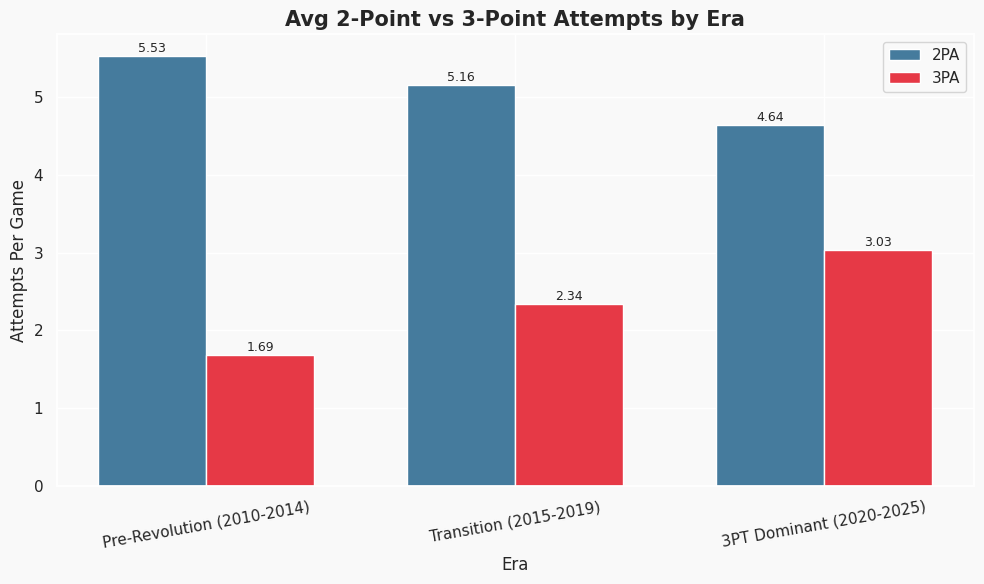

In [9]:
era_order = ["Pre-Revolution (2010-2014)", "Transition (2015-2019)", "3PT Dominant (2020-2025)"]
era_avg = df.groupby('Era')[['2PA','3PA']].mean().reset_index()
era_avg['Era'] = pd.Categorical(era_avg['Era'], categories=era_order, ordered=True)
era_avg = era_avg.sort_values('Era')

x = np.arange(len(era_avg))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, era_avg['2PA'], width, label='2PA', color='#457b9d')
bars2 = ax.bar(x + width/2, era_avg['3PA'], width, label='3PA', color='#e63946')
ax.set_title("Avg 2-Point vs 3-Point Attempts by Era", fontsize=15, fontweight='bold')
ax.set_xlabel("Era"); ax.set_ylabel("Attempts Per Game")
ax.set_xticks(x); ax.set_xticklabels(era_avg['Era'], rotation=10)
ax.legend()

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### Chart 3 — Position-wise 3PA Evolution

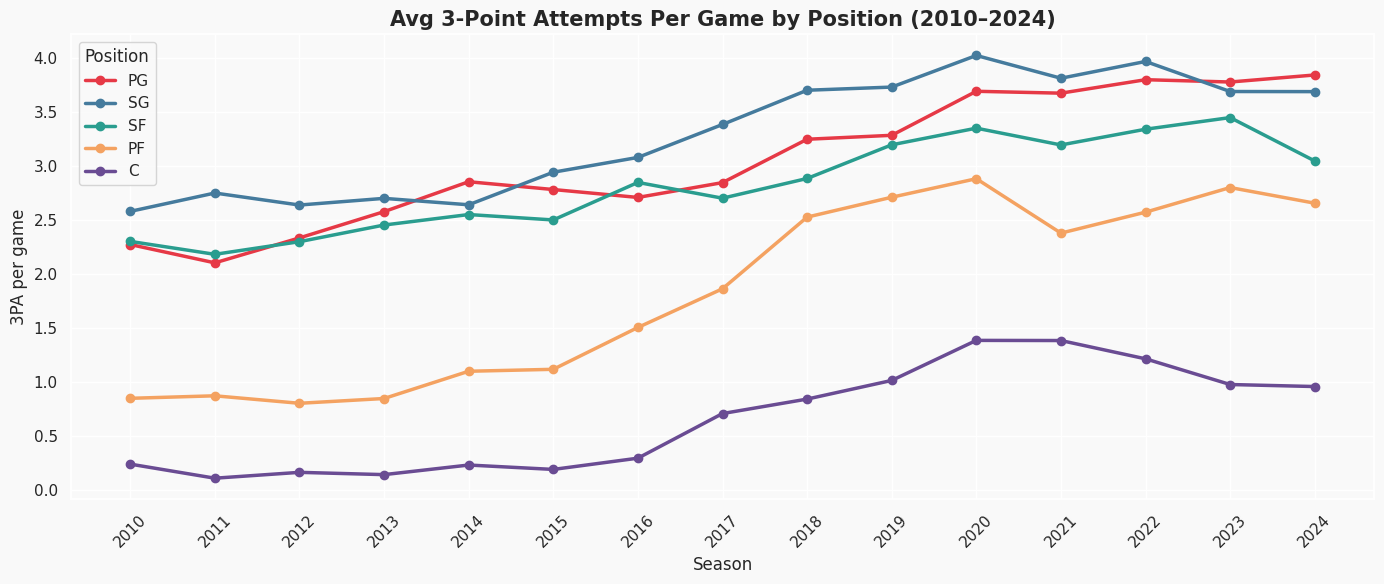

In [10]:
main_pos = ['PG', 'SG', 'SF', 'PF', 'C']
pos_year = df_trend[df_trend['Pos'].isin(main_pos)].groupby(['Year','Pos'])['3PA'].mean().reset_index()
colors = {'PG':'#e63946','SG':'#457b9d','SF':'#2a9d8f','PF':'#f4a261','C':'#6a4c93'}

fig, ax = plt.subplots(figsize=(14, 6))
for pos in main_pos:
    data = pos_year[pos_year['Pos'] == pos]
    ax.plot(data['Year'], data['3PA'], marker='o', label=pos, linewidth=2.5, color=colors[pos])

ax.set_title("Avg 3-Point Attempts Per Game by Position (2010–2024)", fontsize=15, fontweight='bold')
ax.set_xlabel("Season"); ax.set_ylabel("3PA per game")
ax.set_xticks(sorted(df_trend['Year'].unique())); ax.tick_params(axis='x', rotation=45)
ax.legend(title="Position", loc='upper left')
plt.tight_layout()
plt.show()

### Chart 4 — Top 10 Players by 3PT Volume

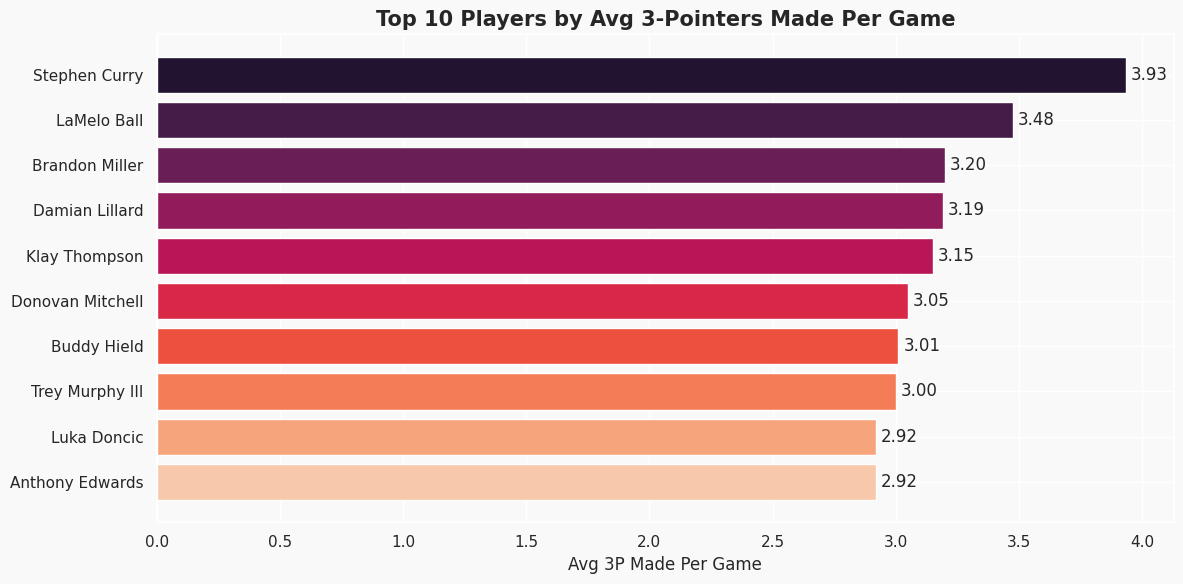

In [11]:
top_volume = (df.groupby('Player')['3P'].mean().reset_index()
              .sort_values('3P', ascending=False).head(10))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_volume['Player'], top_volume['3P'], color=sns.color_palette("rocket", 10))
ax.set_title("Top 10 Players by Avg 3-Pointers Made Per Game", fontsize=15, fontweight='bold')
ax.set_xlabel("Avg 3P Made Per Game"); ax.invert_yaxis()
for bar, val in zip(bars, top_volume['3P']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center')
plt.tight_layout()
plt.show()

### Chart 5 — Top 10 Most Efficient 3PT Shooters (Min 3 Attempts/Game)

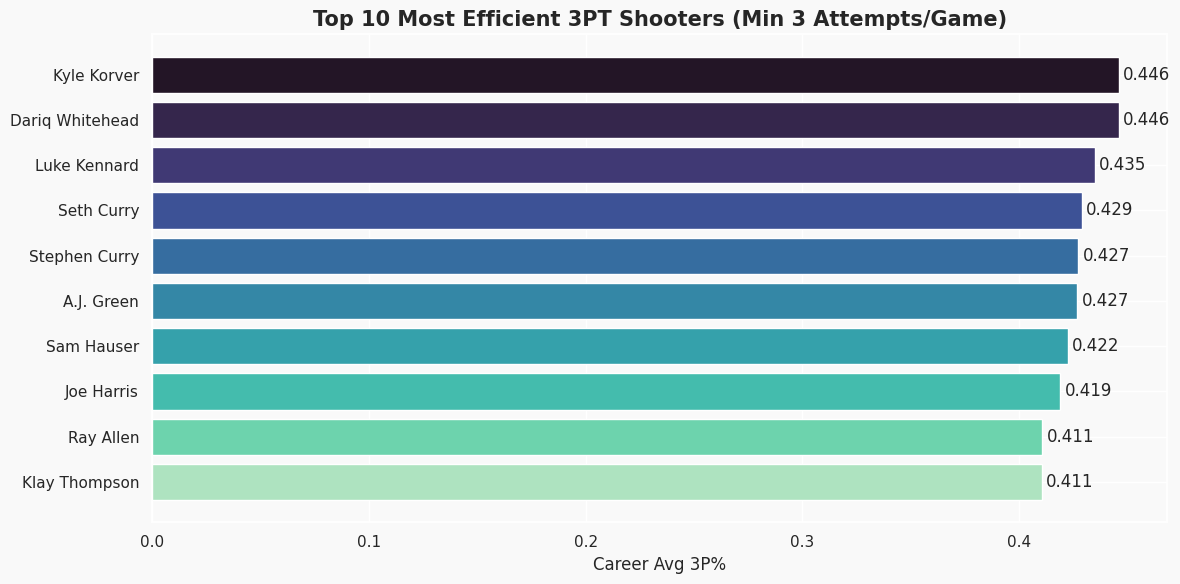

In [12]:
top_eff = (df.groupby('Player').agg({'3P%':'mean','3PA':'mean'}).reset_index())
top_eff = top_eff[top_eff['3PA'] >= 3].sort_values('3P%', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_eff['Player'], top_eff['3P%'], color=sns.color_palette("mako", 10))
ax.set_title("Top 10 Most Efficient 3PT Shooters (Min 3 Attempts/Game)", fontsize=15, fontweight='bold')
ax.set_xlabel("Career Avg 3P%"); ax.invert_yaxis()
for bar, val in zip(bars, top_eff['3P%']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')
plt.tight_layout()
plt.show()

### Chart 6 — Top 10 Scorers (2010–2025)

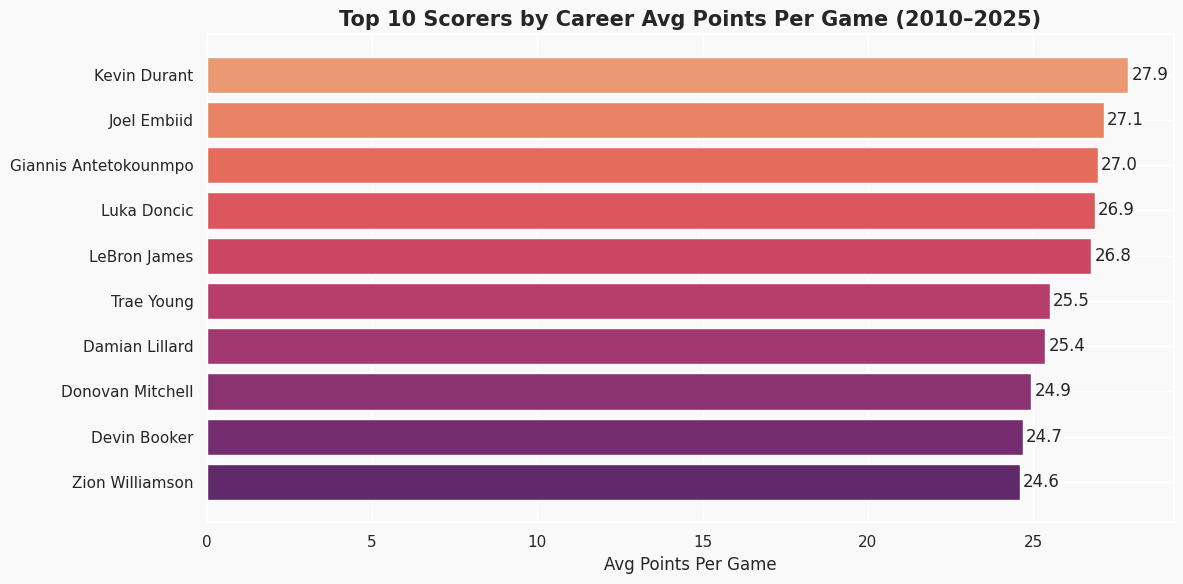

In [13]:
top_scorers = (df.groupby('Player')['PTS'].mean().reset_index()
               .sort_values('PTS', ascending=False).head(10))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_scorers['Player'], top_scorers['PTS'], color=sns.color_palette("flare", 10))
ax.set_title("Top 10 Scorers by Career Avg Points Per Game (2010–2025)", fontsize=15, fontweight='bold')
ax.set_xlabel("Avg Points Per Game"); ax.invert_yaxis()
for bar, val in zip(bars, top_scorers['PTS']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center')
plt.tight_layout()
plt.show()

### Chart 7 — Correlation Heatmap

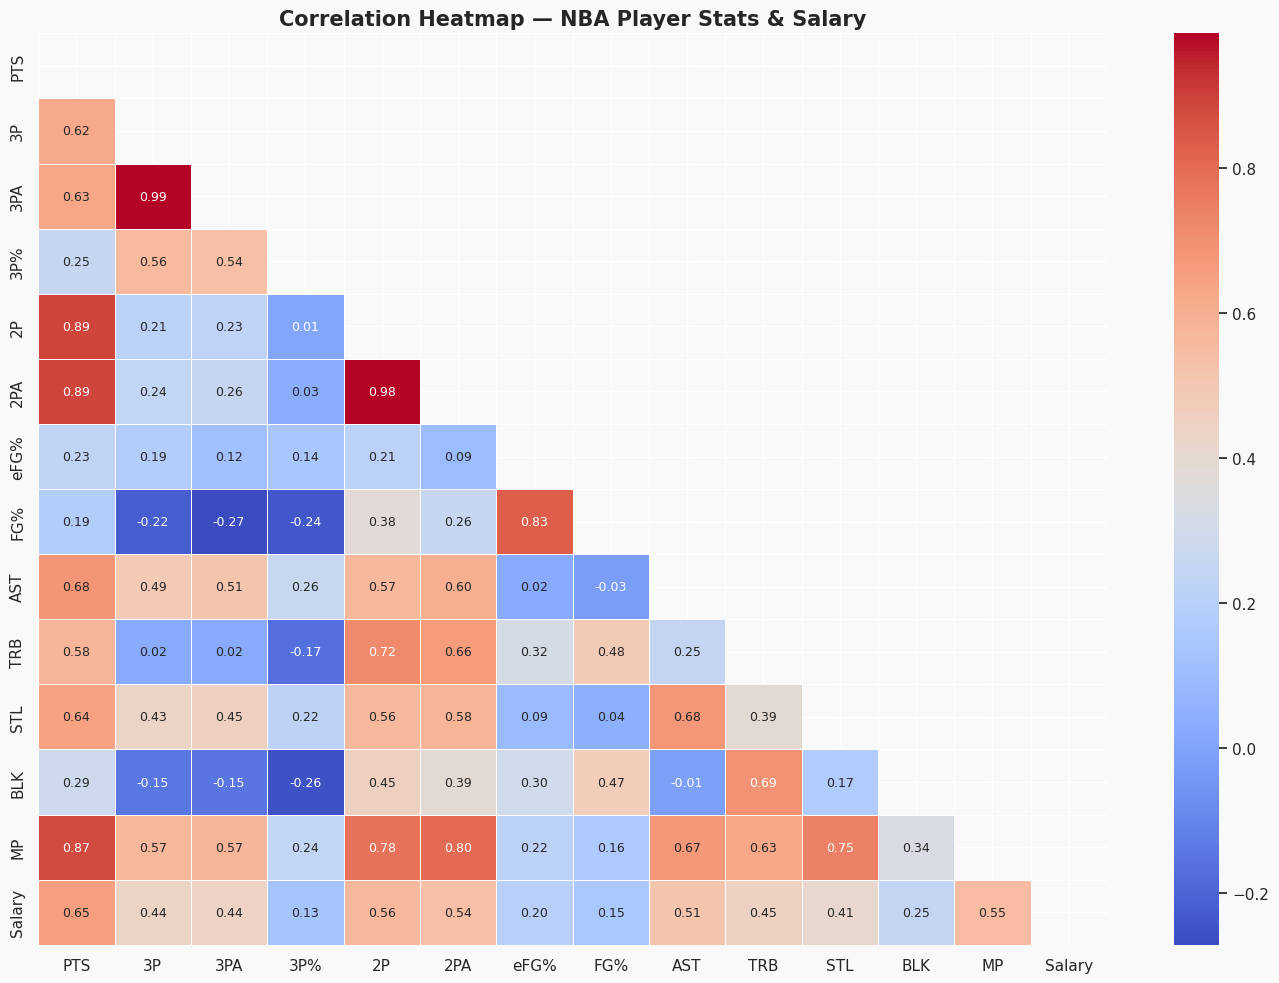

In [14]:
corr_cols = ['PTS','3P','3PA','3P%','2P','2PA','eFG%','FG%','AST','TRB','STL','BLK','MP','Salary']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, linewidths=0.5, annot_kws={"size": 9})
ax.set_title("Correlation Heatmap — NBA Player Stats & Salary", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Chart 8 — eFG% vs Salary (Scatter Plot)

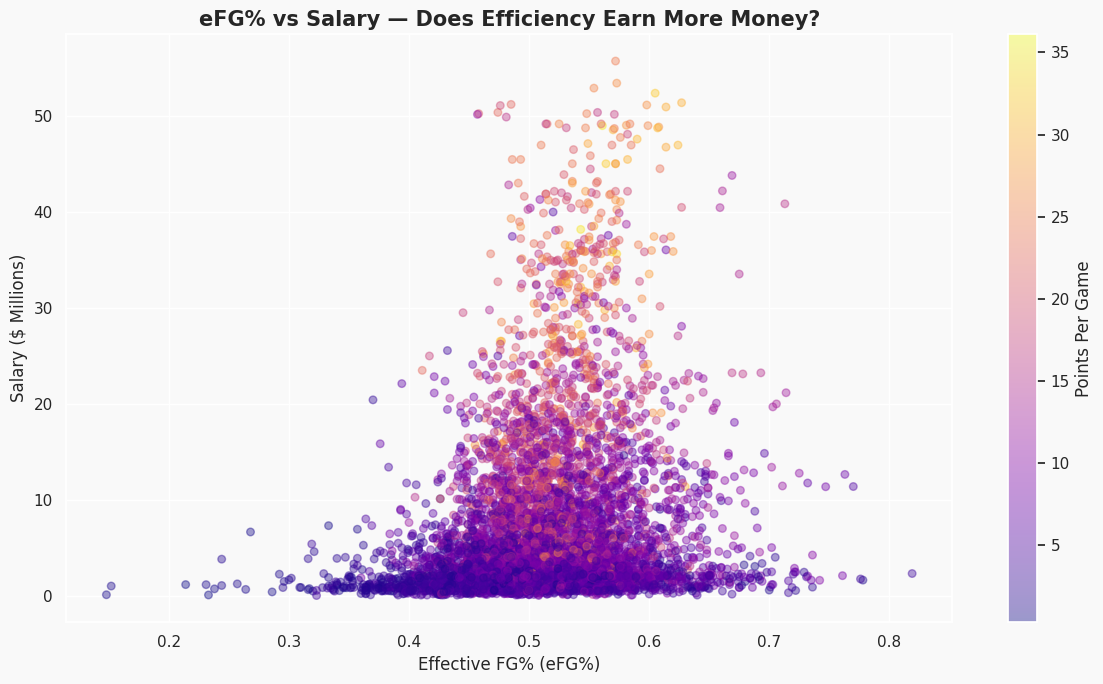

In [15]:
scatter_df = df[(df['eFG%'] > 0) & (df['Salary'] > 0) & (df['G'] >= 20)]

fig, ax = plt.subplots(figsize=(12, 7))
sc = ax.scatter(scatter_df['eFG%'], scatter_df['Salary'] / 1e6,
                alpha=0.4, c=scatter_df['PTS'], cmap='plasma', s=30)
plt.colorbar(sc, ax=ax, label='Points Per Game')
ax.set_title("eFG% vs Salary — Does Efficiency Earn More Money?", fontsize=15, fontweight='bold')
ax.set_xlabel("Effective FG% (eFG%)")
ax.set_ylabel("Salary ($ Millions)")
plt.tight_layout()
plt.show()

### Chart 9 — Points Distribution by Position (Box Plot)

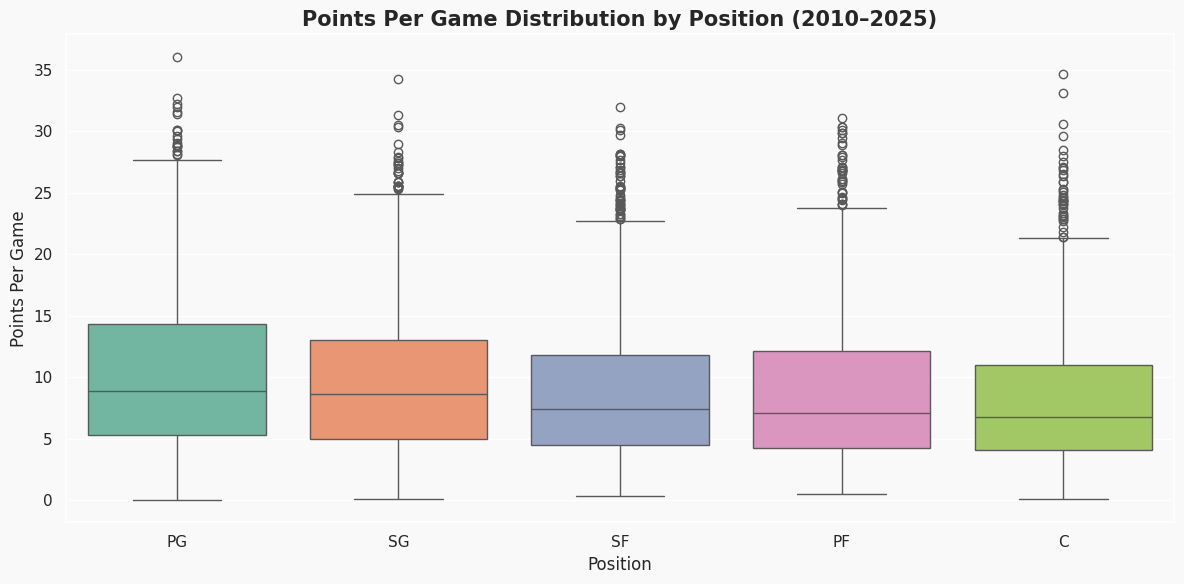

In [16]:
pos_df = df[df['Pos'].isin(main_pos)]

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=pos_df, x='Pos', y='PTS', order=main_pos, palette='Set2', ax=ax)
ax.set_title("Points Per Game Distribution by Position (2010–2025)", fontsize=15, fontweight='bold')
ax.set_xlabel("Position"); ax.set_ylabel("Points Per Game")
plt.tight_layout()
plt.show()

### Chart 10 — 3P% Distribution (Histogram)

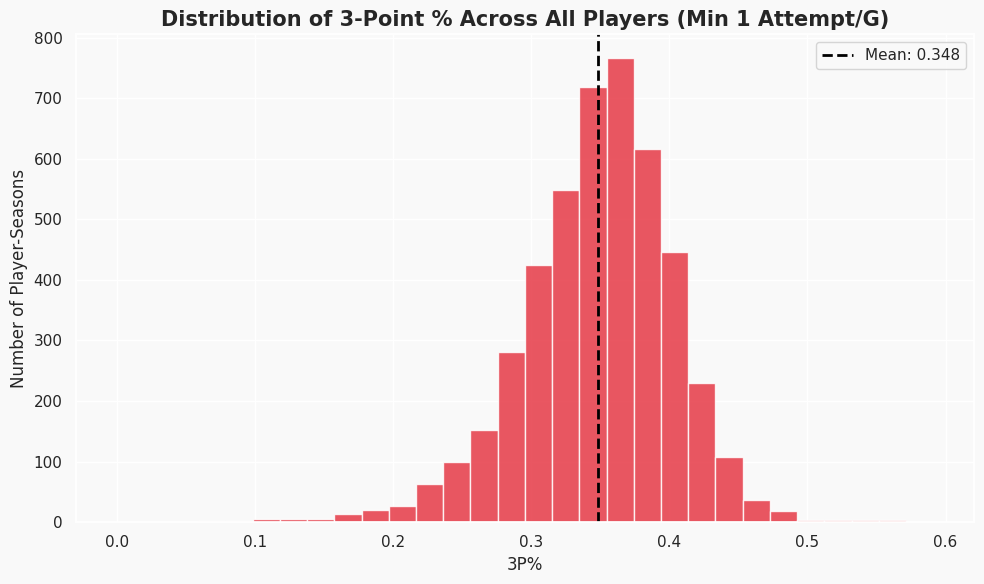

In [17]:
hist_df = df[df['3PA'] >= 1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(hist_df['3P%'], bins=30, color='#e63946', edgecolor='white', alpha=0.85)
ax.axvline(hist_df['3P%'].mean(), color='black', linestyle='--', linewidth=2,
           label=f"Mean: {hist_df['3P%'].mean():.3f}")
ax.set_title("Distribution of 3-Point % Across All Players (Min 1 Attempt/G)", fontsize=15, fontweight='bold')
ax.set_xlabel("3P%"); ax.set_ylabel("Number of Player-Seasons")
ax.legend()
plt.tight_layout()
plt.show()

### Chart 11 — Shot Share (2PT vs 3PT) by Era (Pie Charts)

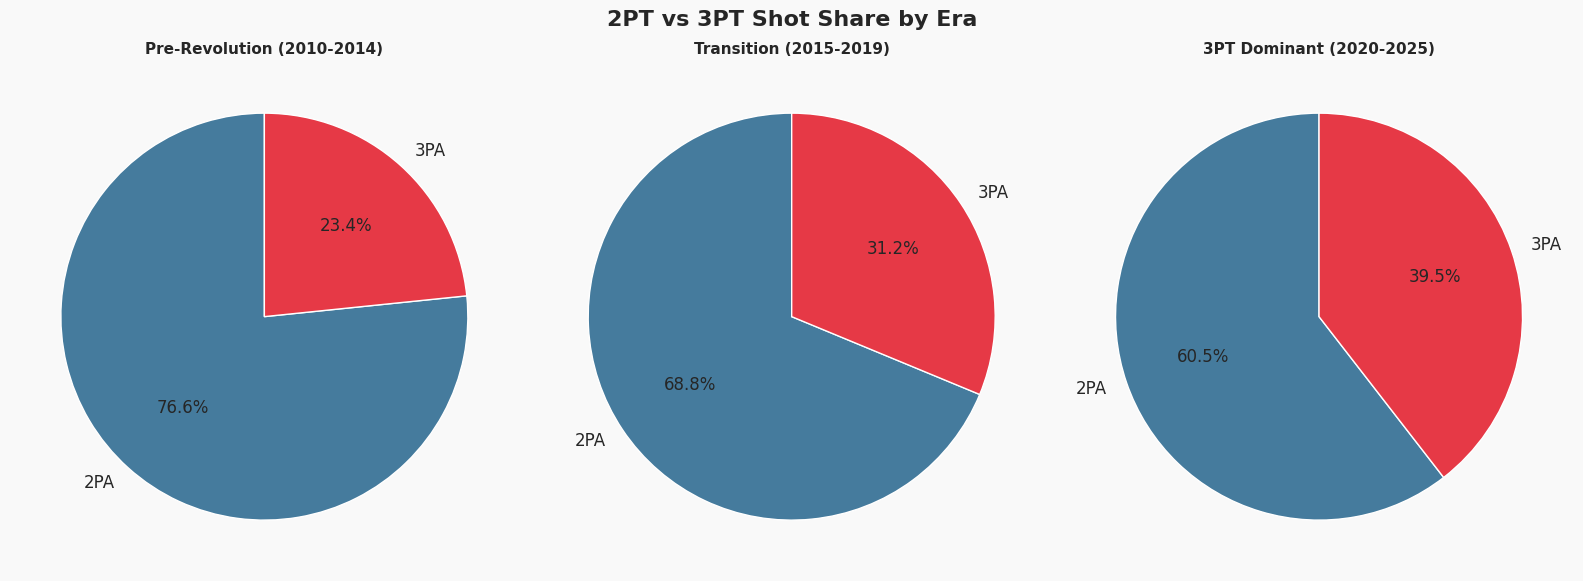

In [18]:
era_shots = df.groupby('Era')[['2PA','3PA']].sum().reset_index()
era_shots['Era'] = pd.Categorical(era_shots['Era'], categories=era_order, ordered=True)
era_shots = era_shots.sort_values('Era')

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("2PT vs 3PT Shot Share by Era", fontsize=16, fontweight='bold')

for i, (_, row) in enumerate(era_shots.iterrows()):
    axes[i].pie([row['2PA'], row['3PA']], labels=['2PA', '3PA'],
                autopct='%1.1f%%', colors=['#457b9d','#e63946'],
                startangle=90, textprops={'fontsize':12})
    axes[i].set_title(row['Era'], fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### Chart 12 — Top 10 Highest Paid Players vs eFG%

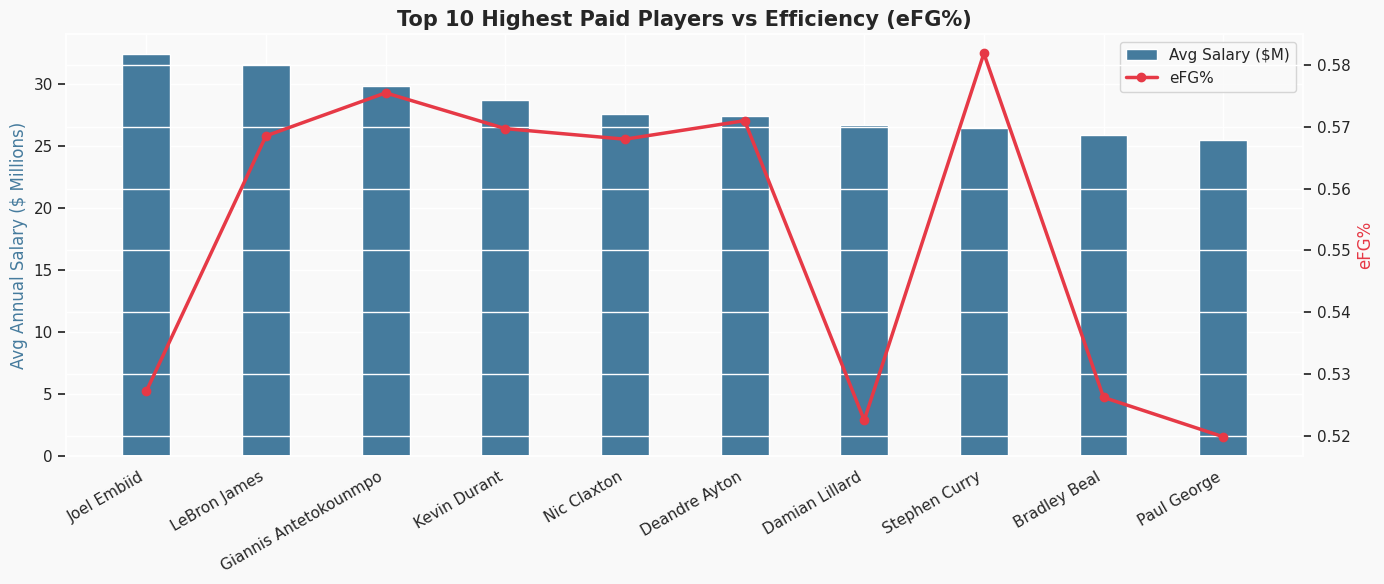

In [19]:
top_paid = (df.groupby('Player').agg({'Salary':'mean','eFG%':'mean','PTS':'mean'})
            .reset_index().sort_values('Salary', ascending=False).head(10))

x = np.arange(len(top_paid))
width = 0.4

fig, ax1 = plt.subplots(figsize=(14, 6))
bars = ax1.bar(x, top_paid['Salary'] / 1e6, width, color='#457b9d', label='Avg Salary ($M)')
ax1.set_ylabel("Avg Annual Salary ($ Millions)", color='#457b9d')
ax1.set_xticks(x); ax1.set_xticklabels(top_paid['Player'], rotation=30, ha='right')
ax1.set_title("Top 10 Highest Paid Players vs Efficiency (eFG%)", fontsize=15, fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(x, top_paid['eFG%'], color='#e63946', marker='o', linewidth=2.5, label='eFG%')
ax2.set_ylabel("eFG%", color='#e63946')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.show()

## Step 6 — Key Findings

## Step 6B — Most Improved Players (Year-over-Year)

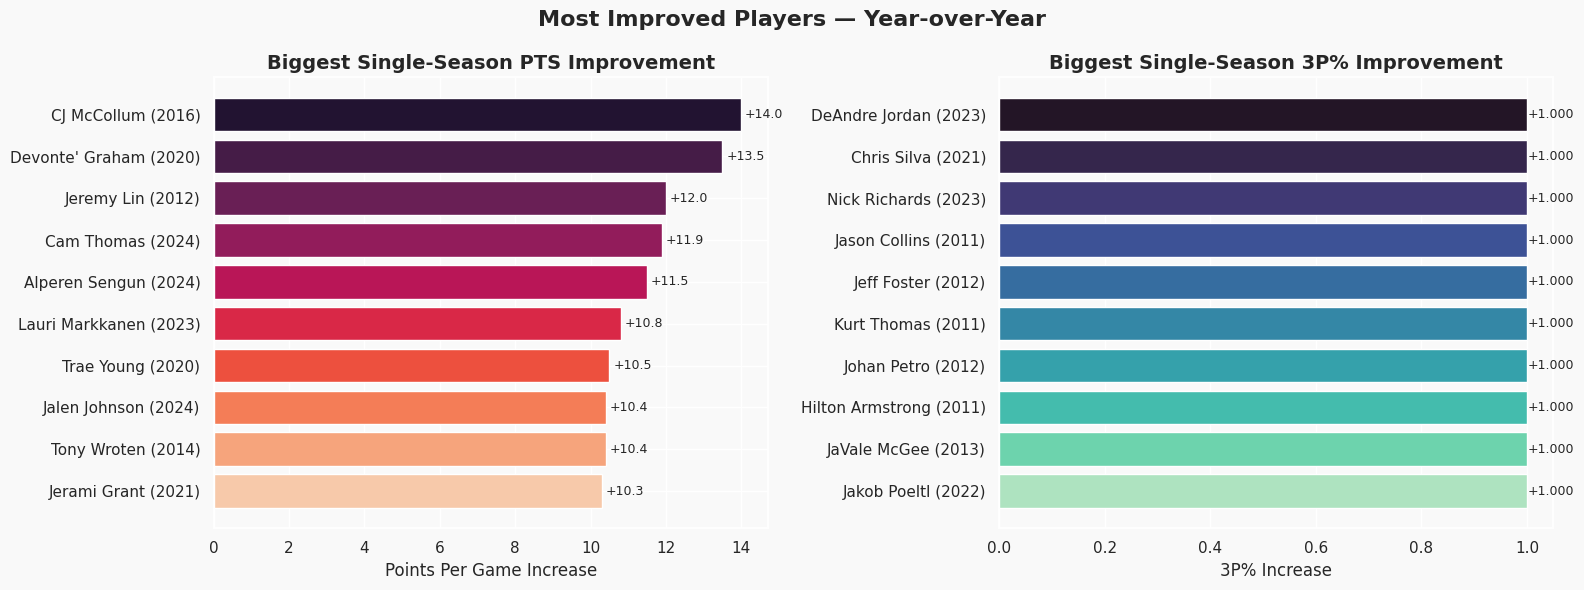

Top 10 Most Improved Players by PTS:
         Player  Year  PTS_change
    CJ McCollum  2016        14.0
Devonte' Graham  2020        13.5
     Jeremy Lin  2012        12.0
     Cam Thomas  2024        11.9
 Alperen Sengun  2024        11.5
Lauri Markkanen  2023        10.8
     Trae Young  2020        10.5
  Jalen Johnson  2024        10.4
    Tony Wroten  2014        10.4
   Jerami Grant  2021        10.3


In [20]:
# Most Improved Players by Points Per Game (Year-over-Year)
player_year = df_trend.groupby(['Player','Year'])[['3P%','PTS']].mean().reset_index()
player_year = player_year.sort_values(['Player','Year'])
player_year['PTS_change'] = player_year.groupby('Player')['PTS'].diff()
player_year['3P%_change'] = player_year.groupby('Player')['3P%'].diff()

most_improved_pts = (player_year.dropna(subset=['PTS_change'])
                     .sort_values('PTS_change', ascending=False).head(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Most Improved Players — Year-over-Year", fontsize=16, fontweight='bold')

# By PTS
bars1 = axes[0].barh(
    most_improved_pts['Player'] + ' (' + most_improved_pts['Year'].astype(str) + ')',
    most_improved_pts['PTS_change'],
    color=sns.color_palette("rocket", 10)
)
axes[0].set_title("Biggest Single-Season PTS Improvement", fontweight='bold')
axes[0].set_xlabel("Points Per Game Increase")
axes[0].invert_yaxis()
for bar, val in zip(bars1, most_improved_pts['PTS_change']):
    axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'+{val:.1f}', va='center', fontsize=9)

# By 3P%
most_improved_3p = (player_year.dropna(subset=['3P%_change'])
                    [player_year['3P%_change'] > 0]
                    .sort_values('3P%_change', ascending=False).head(10))
bars2 = axes[1].barh(
    most_improved_3p['Player'] + ' (' + most_improved_3p['Year'].astype(str) + ')',
    most_improved_3p['3P%_change'],
    color=sns.color_palette("mako", 10)
)
axes[1].set_title("Biggest Single-Season 3P% Improvement", fontweight='bold')
axes[1].set_xlabel("3P% Increase")
axes[1].invert_yaxis()
for bar, val in zip(bars2, most_improved_3p['3P%_change']):
    axes[1].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'+{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Top 10 Most Improved Players by PTS:")
print(most_improved_pts[['Player','Year','PTS_change']].to_string(index=False))

## Step 6C — NBA Salary Growth Over Seasons (2010–2024)

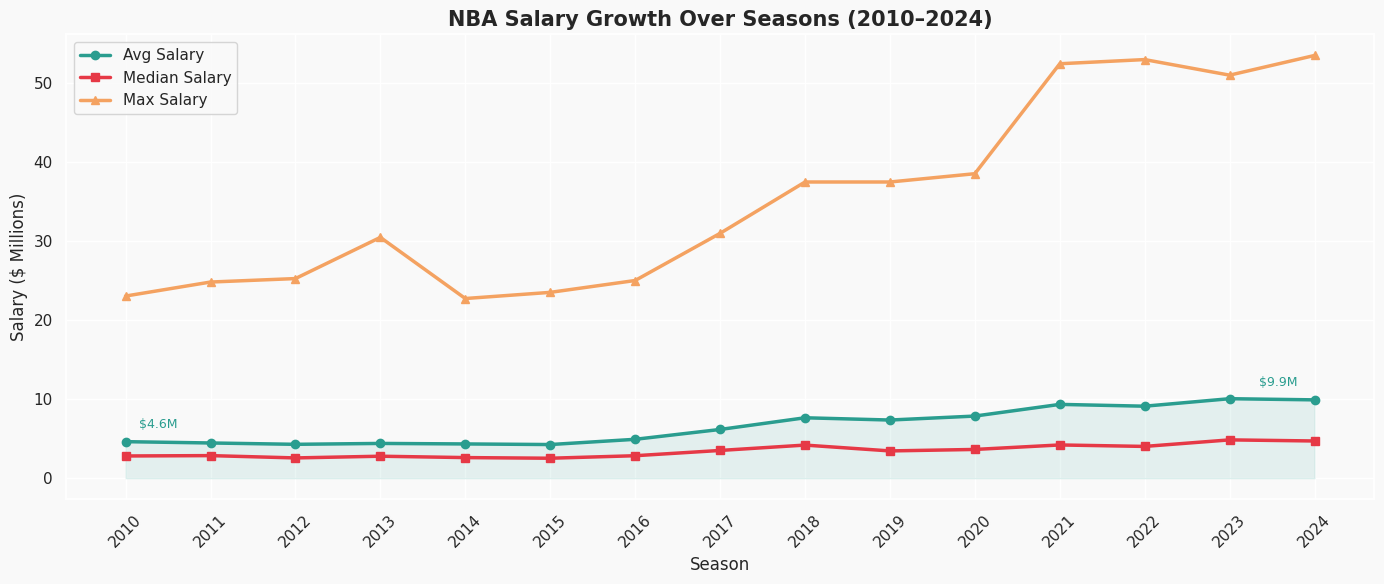

Average NBA salary grew by 114.4% from 2010 to 2024
From $4.62M to $9.91M


In [21]:
# Average Salary Growth per Season
sal_growth = df_trend.groupby('Year')['Salary'].agg(['mean','median','max']).reset_index()
sal_growth.columns = ['Year','Avg Salary','Median Salary','Max Salary']

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(sal_growth['Year'], sal_growth['Avg Salary']/1e6,
        marker='o', color='#2a9d8f', linewidth=2.5, label='Avg Salary')
ax.plot(sal_growth['Year'], sal_growth['Median Salary']/1e6,
        marker='s', color='#e63946', linewidth=2.5, label='Median Salary')
ax.plot(sal_growth['Year'], sal_growth['Max Salary']/1e6,
        marker='^', color='#f4a261', linewidth=2.5, label='Max Salary')

ax.fill_between(sal_growth['Year'], sal_growth['Avg Salary']/1e6, alpha=0.1, color='#2a9d8f')
ax.set_title("NBA Salary Growth Over Seasons (2010–2024)", fontsize=15, fontweight='bold')
ax.set_xlabel("Season")
ax.set_ylabel("Salary ($ Millions)")
ax.set_xticks(sal_growth['Year'])
ax.tick_params(axis='x', rotation=45)
ax.legend()

# Annotate start and end avg salary
ax.annotate(f"${sal_growth['Avg Salary'].iloc[0]/1e6:.1f}M",
            xy=(sal_growth['Year'].iloc[0], sal_growth['Avg Salary'].iloc[0]/1e6),
            xytext=(10, 10), textcoords='offset points', fontsize=9, color='#2a9d8f')
ax.annotate(f"${sal_growth['Avg Salary'].iloc[-1]/1e6:.1f}M",
            xy=(sal_growth['Year'].iloc[-1], sal_growth['Avg Salary'].iloc[-1]/1e6),
            xytext=(-40, 10), textcoords='offset points', fontsize=9, color='#2a9d8f')

plt.tight_layout()
plt.show()

growth_pct = ((sal_growth['Avg Salary'].iloc[-1] - sal_growth['Avg Salary'].iloc[0])
              / sal_growth['Avg Salary'].iloc[0]) * 100
print(f"Average NBA salary grew by {growth_pct:.1f}% from 2010 to 2024")
print(f"From ${sal_growth['Avg Salary'].iloc[0]/1e6:.2f}M to ${sal_growth['Avg Salary'].iloc[-1]/1e6:.2f}M")

## Step 6D — Age vs Performance Analysis (Peak Age Study)

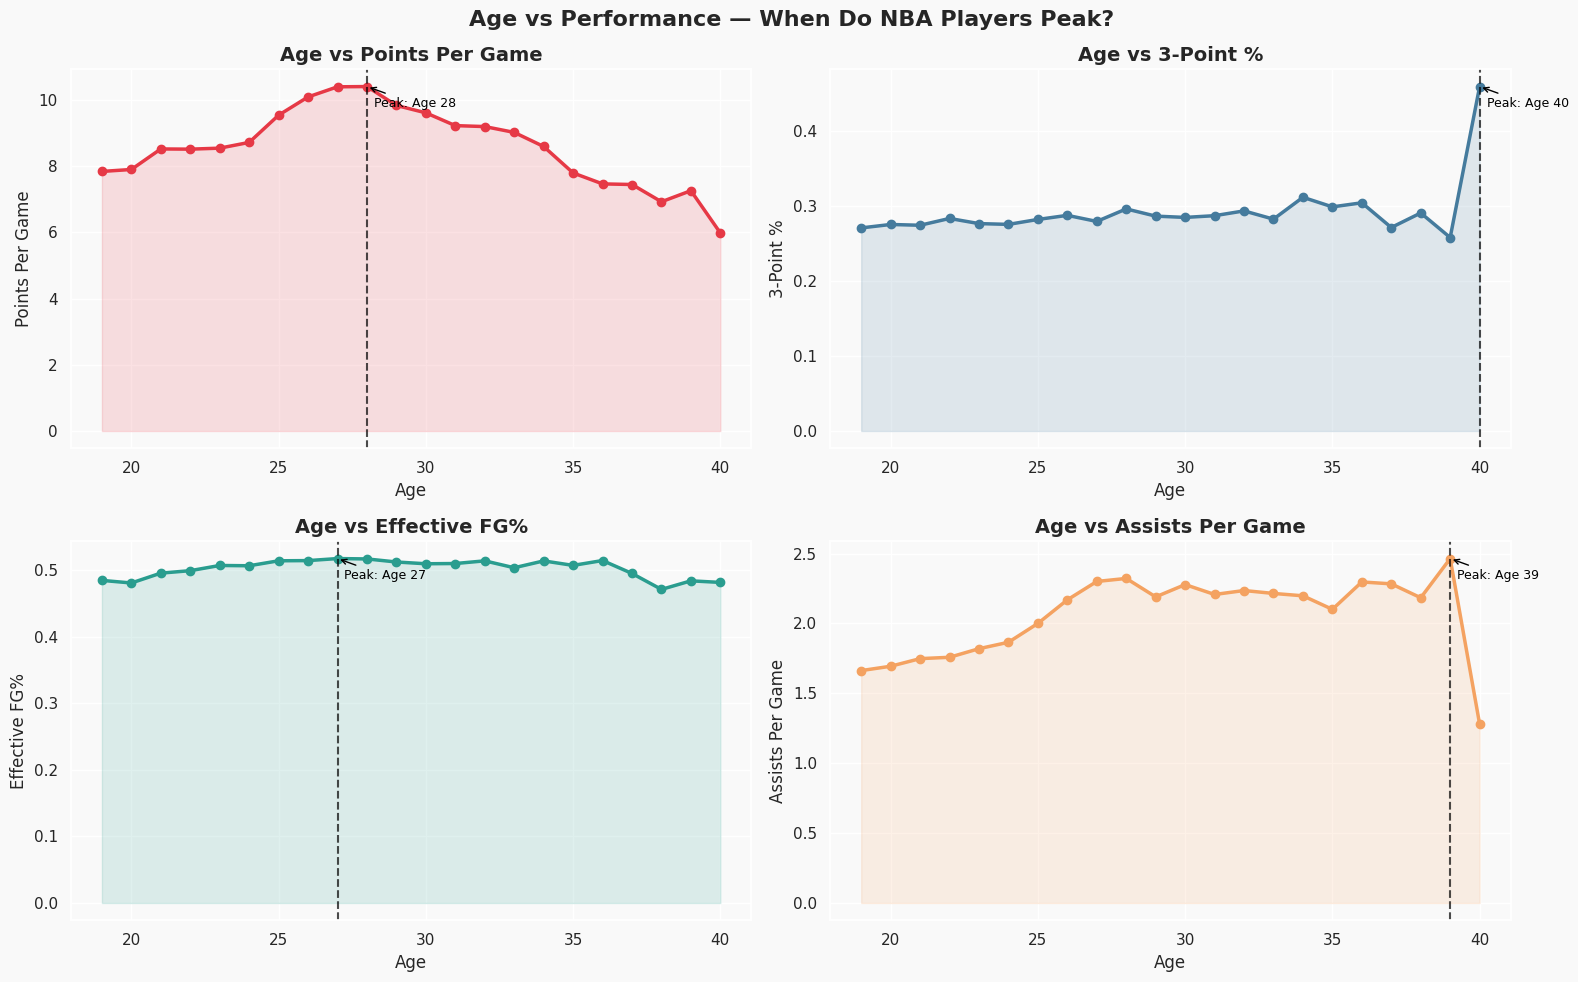

Peak Ages by Metric:
  Points Per Game          : Age 28
  3-Point %                : Age 40
  Effective FG%            : Age 27
  Assists Per Game         : Age 39


In [22]:
# Age vs Performance — At what age do players peak?
age_perf = df_trend.groupby('Age')[['PTS','3P%','eFG%','AST','TRB']].mean().reset_index()
age_perf = age_perf[(age_perf['Age'] >= 18) & (age_perf['Age'] <= 40)]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Age vs Performance — When Do NBA Players Peak?",
             fontsize=16, fontweight='bold')

metrics = [('PTS','Points Per Game','#e63946'),
           ('3P%','3-Point %','#457b9d'),
           ('eFG%','Effective FG%','#2a9d8f'),
           ('AST','Assists Per Game','#f4a261')]

for ax, (col, label, color) in zip(axes.flatten(), metrics):
    ax.plot(age_perf['Age'], age_perf[col], marker='o', color=color, linewidth=2.5)
    ax.fill_between(age_perf['Age'], age_perf[col], alpha=0.15, color=color)

    peak_age = age_perf.loc[age_perf[col].idxmax(), 'Age']
    peak_val = age_perf[col].max()
    ax.axvline(peak_age, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.annotate(f'Peak: Age {peak_age}',
                xy=(peak_age, peak_val),
                xytext=(5, -15), textcoords='offset points',
                fontsize=9, color='black',
                arrowprops=dict(arrowstyle='->', color='black'))

    ax.set_title(f"Age vs {label}", fontweight='bold')
    ax.set_xlabel("Age"); ax.set_ylabel(label)

plt.tight_layout()
plt.show()

print("Peak Ages by Metric:")
for col, label, _ in metrics:
    peak = age_perf.loc[age_perf[col].idxmax(), 'Age']
    print(f"  {label:25s}: Age {peak}")

## Step 6E — Team-wise Analysis (Best 3-Point Teams)

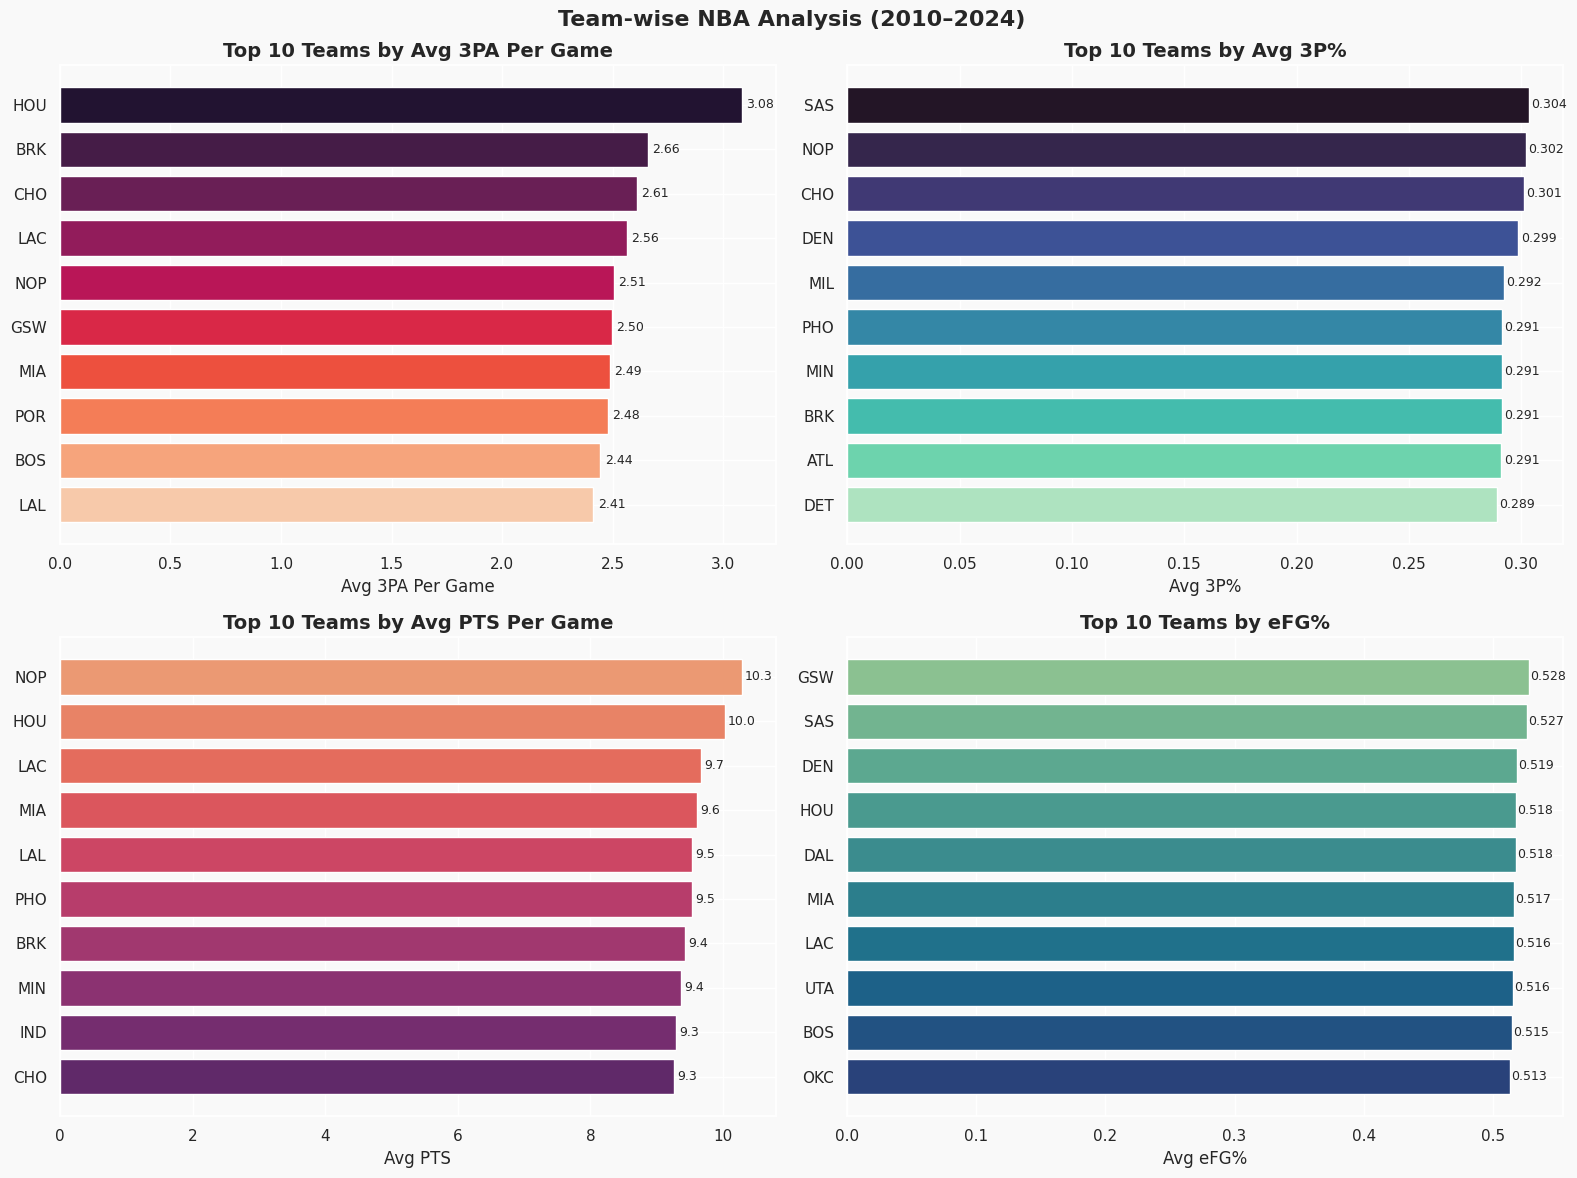

Top 5 Teams by 3PA:
Team      3PA
 HOU 3.084615
 BRK 2.658382
 CHO 2.611024
 LAC 2.563636
 NOP 2.507042
Top 5 Teams by PTS:
Team       PTS
 NOP 10.283803
 HOU 10.025275
 LAC  9.673684
 MIA  9.604762
 LAL  9.537500


In [23]:
# Team-wise Analysis
team_stats = (df_trend.groupby('Team')
              .agg({'3PA':'mean', '3P%':'mean', 'PTS':'mean', 'eFG%':'mean'})
              .reset_index())

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Team-wise NBA Analysis (2010–2024)", fontsize=16, fontweight='bold')

# Top 10 teams by 3PA
top_3pa = team_stats.sort_values('3PA', ascending=False).head(10)
bars1 = axes[0][0].barh(top_3pa['Team'], top_3pa['3PA'],
                         color=sns.color_palette("rocket", 10))
axes[0][0].set_title("Top 10 Teams by Avg 3PA Per Game", fontweight='bold')
axes[0][0].set_xlabel("Avg 3PA Per Game"); axes[0][0].invert_yaxis()
for bar, val in zip(bars1, top_3pa['3PA']):
    axes[0][0].text(bar.get_width()+0.02, bar.get_y()+bar.get_height()/2,
                    f'{val:.2f}', va='center', fontsize=9)

# Top 10 teams by 3P%
top_3pct = team_stats.sort_values('3P%', ascending=False).head(10)
bars2 = axes[0][1].barh(top_3pct['Team'], top_3pct['3P%'],
                         color=sns.color_palette("mako", 10))
axes[0][1].set_title("Top 10 Teams by Avg 3P%", fontweight='bold')
axes[0][1].set_xlabel("Avg 3P%"); axes[0][1].invert_yaxis()
for bar, val in zip(bars2, top_3pct['3P%']):
    axes[0][1].text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
                    f'{val:.3f}', va='center', fontsize=9)

# Top 10 teams by PTS
top_pts = team_stats.sort_values('PTS', ascending=False).head(10)
bars3 = axes[1][0].barh(top_pts['Team'], top_pts['PTS'],
                         color=sns.color_palette("flare", 10))
axes[1][0].set_title("Top 10 Teams by Avg PTS Per Game", fontweight='bold')
axes[1][0].set_xlabel("Avg PTS"); axes[1][0].invert_yaxis()
for bar, val in zip(bars3, top_pts['PTS']):
    axes[1][0].text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
                    f'{val:.1f}', va='center', fontsize=9)

# Top 10 teams by eFG%
top_efg = team_stats.sort_values('eFG%', ascending=False).head(10)
bars4 = axes[1][1].barh(top_efg['Team'], top_efg['eFG%'],
                         color=sns.color_palette("crest", 10))
axes[1][1].set_title("Top 10 Teams by eFG%", fontweight='bold')
axes[1][1].set_xlabel("Avg eFG%"); axes[1][1].invert_yaxis()
for bar, val in zip(bars4, top_efg['eFG%']):
    axes[1][1].text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
                    f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Top 5 Teams by 3PA:")
print(top_3pa[['Team','3PA']].head(5).to_string(index=False))
print("Top 5 Teams by PTS:")
print(top_pts[['Team','PTS']].head(5).to_string(index=False))

In [24]:
first_3pa = season_avg[season_avg['Year'] == 2010]['3PA'].values[0]
last_3pa  = season_avg[season_avg['Year'] == 2024]['3PA'].values[0]
pct_change_3pa = ((last_3pa - first_3pa) / first_3pa) * 100

first_efg = season_avg[season_avg['Year'] == 2010]['eFG%'].values[0]
last_efg  = season_avg[season_avg['Year'] == 2024]['eFG%'].values[0]

c_2010 = df_trend[(df_trend['Pos']=='C') & (df_trend['Year']==2010)]['3PA'].mean()
c_2024 = df_trend[(df_trend['Pos']=='C') & (df_trend['Year']==2024)]['3PA'].mean()

era_shots = df.groupby('Era')[['2PA','3PA']].sum().reset_index()
era_shots['Era'] = pd.Categorical(era_shots['Era'], categories=era_order, ordered=True)
era_shots = era_shots.sort_values('Era')

print(f"""
KEY FINDINGS
══════════════════════════════════════════════════════════
1. Avg 3-Point Attempts Per Game rose from {first_3pa:.2f} (2010)
   to {last_3pa:.2f} (2024) — a {pct_change_3pa:.1f}% increase.

2. Effective FG% improved from {first_efg:.3f} (2010) to {last_efg:.3f} (2024),
   reflecting more efficient shot selection leaguewide.

3. Centers averaged only {c_2010:.2f} 3PA/game in 2010.
   By 2024 that rose to {c_2024:.2f} — even big men now shoot from deep.

4. The biggest jump in 3PA came during the Transition Era (2015-2019),
   driven by the Golden State Warriors and Stephen Curry's influence.

5. Shot share nearly doubled:
   Pre-Revolution era : ~{era_shots.iloc[0]['3PA']/(era_shots.iloc[0]['2PA']+era_shots.iloc[0]['3PA'])*100:.1f}% of shots were 3-pointers
   3PT Dominant era   : ~{era_shots.iloc[2]['3PA']/(era_shots.iloc[2]['2PA']+era_shots.iloc[2]['3PA'])*100:.1f}% of shots are 3-pointers
══════════════════════════════════════════════════════════
""")


KEY FINDINGS
══════════════════════════════════════════════════════════
1. Avg 3-Point Attempts Per Game rose from 1.62 (2010)
   to 2.89 (2024) — a 78.6% increase.

2. Effective FG% improved from 0.491 (2010) to 0.538 (2024),
   reflecting more efficient shot selection leaguewide.

3. Centers averaged only 0.24 3PA/game in 2010.
   By 2024 that rose to 0.96 — even big men now shoot from deep.

4. The biggest jump in 3PA came during the Transition Era (2015-2019),
   driven by the Golden State Warriors and Stephen Curry's influence.

5. Shot share nearly doubled:
   Pre-Revolution era : ~23.4% of shots were 3-pointers
   3PT Dominant era   : ~39.5% of shots are 3-pointers
══════════════════════════════════════════════════════════



## Step 7 — Conclusion

This project analyzed **NBA player stats and salary data from 2010 to 2025** to understand the evolution of 3-point shooting and scoring efficiency.

### Summary of Findings:
- The NBA has undergone a **massive 3-point revolution** — attempts nearly doubled over 15 seasons
- **Scoring efficiency (eFG%)** improved steadily as teams embraced smarter shot selection
- **All positions** adopted the 3-pointer, most dramatically Centers who went from almost never shooting 3s to becoming a regular part of their game
- The **Transition Era (2015–2019)** was the turning point, heavily influenced by the Golden State Warriors dynasty
- Shot share shifted from ~23% 3-point shots to ~40%, fundamentally changing how basketball is played
- **Salary correlates loosely with performance** — high scorers tend to earn more, but efficiency alone doesn't guarantee top pay

### Future Scope:
- Add playoff statistics for deeper performance analysis
- Build a machine learning model to predict player salary from stats
- Incorporate team-level data to analyze how team strategy influenced individual stats
- Extend to game-by-game data for quarter/half-level analysis